In [1]:
import numpy as np
import matplotlib.pyplot as plt
import uproot
import particle
from particle import Particle

#PATH = pathlib.Path(__file__).parent.resolve()
DET_I = 5 #SBND ?
DET_A = 4*np.pi*1e4# Find detector area

flavours = {
     14: (r"$\nu_\mu$",     "blue"),
    -14: (r"$\bar\nu_\mu$", "orange"),
     12: (r"$\nu_e$",       "green"),
    -12: (r"$\bar\nu_e$",   "red"),
}


In [2]:
with uproot.open("./DATA/NuBeam_production_BooNE_50m_I174000A_0.dk2nu.root") as f:
    
    print(f.keys())
    tree = f[f.keys()[0]]
    meta = f[f.keys()[2]]

    nuray_E   = tree["nuray"]["nuray.E"].array()
    nuray_wgt = tree["nuray"]["nuray.wgt"].array()
    nimpwt    = tree["decay"]["decay.nimpwt"].array()
    ntype     = tree["decay"]["decay.ntype"].array()
    ptype     = tree["decay"]["decay.ptype"].array() 
    pots = meta["pots"].array()

    '''
    for entry in meta:
        print(entry.name)
        for entry2 in entry:
            print("\t",entry2.name)
            for entry3 in entry2:
                print("\t\t",entry3.name)
    '''

    print(meta["location"]["location.x"].array())
    print(meta["location"]["location.y"].array())
    print(meta["location"]["location.z"].array())

['dk2nuTree;2', 'dk2nuTree;1', 'dkmetaTree;1']
[[0, 0, 0, 0, 0]]
[[190, 0, 0, 0, 0]]
[[5.41e+04, 4.7e+04, 1e+04, 6e+04, 1.1e+04]]


In [28]:
# Select SBND
energies = nuray_E[:,DET_I]
wgts     = nuray_wgt[:,DET_I]
tot_wgts = nimpwt * wgts / (DET_A * pots[0])

# Type and Parents
is_numu      = (ntype == 14)
is_anumu     = (ntype == -14)
is_nue       = (ntype == 12)
is_anue      = (ntype == -12)

parent_groups = {
    "mu" : (np.isin(ptype, [13,-13]), "blue"),
    "pi" : (np.isin(ptype, [211,-211]), "orange"),
    "K0L" : (np.isin(ptype, [130]), "red"),
    "Kpm" : (np.isin(ptype, [321, -321]), "green")
}

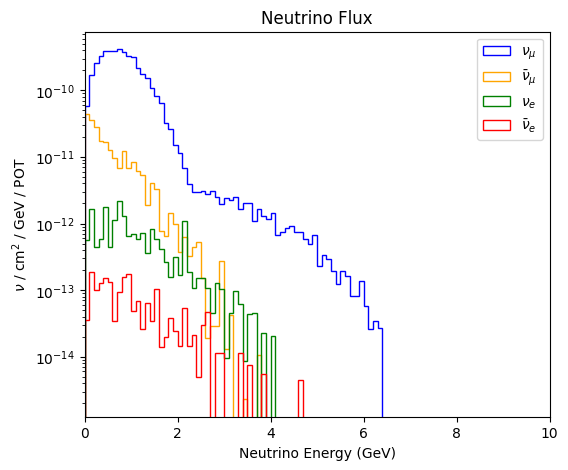

In [29]:
fig, ax = plt.subplots(figsize=(6, 5))
bins = np.linspace(0, 10, 101)  # GeV


for pdg, (label, colour) in flavours.items():
    mask = (ntype == pdg)
    ax.hist(energies[mask], bins=bins, weights=tot_wgts[mask],
            label=label, color=colour, histtype="step", linewidth=1)

ax.set_xlabel("Neutrino Energy (GeV)")
ax.set_xlim(0,10)
ax.set_ylabel(r"$\nu$ / cm$^2$ / GeV / POT")
ax.set_title("Neutrino Flux")
ax.legend()
ax.set_yscale("log")

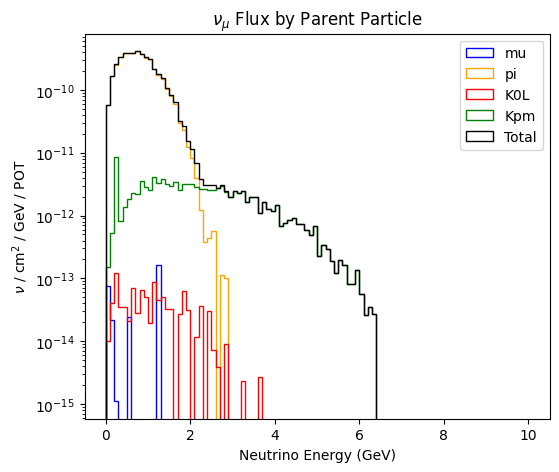

In [30]:
fig, ax = plt.subplots(figsize=(6, 5))
bins = np.linspace(0, 10, 101)  # GeV

for label, (parent_mask, colour) in parent_groups.items():
    mask = is_numu & parent_mask
    ax.hist(energies[mask], bins=bins, weights=tot_wgts[mask],
            label=label, color=colour, histtype="step", linewidth=1)

# Total Flux
ax.hist(energies[is_numu], bins=bins, weights=tot_wgts[is_numu], label="Total", 
        color="black", histtype="step", linewidth=1)

ax.set_xlabel("Neutrino Energy (GeV)")
ax.set_ylabel(r"$\nu$ / cm$^2$ / GeV / POT")
ax.set_title(r"$\nu_\mu$ Flux by Parent Particle")
ax.legend()
ax.set_yscale("log")
#ax.set_xlim(0,1)

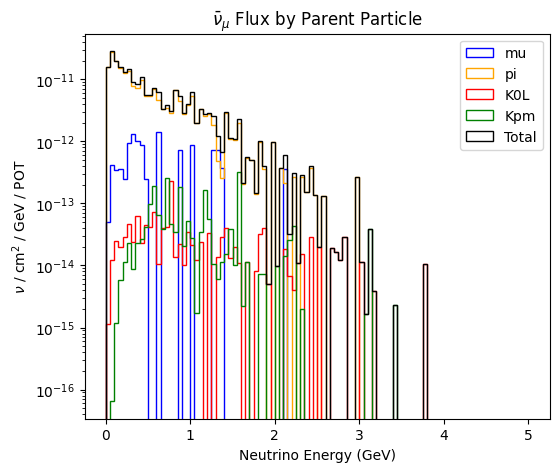

In [31]:
fig, ax = plt.subplots(figsize=(6, 5))
bins = np.linspace(0, 5, 101)  # GeV

for label, (parent_mask, colour) in parent_groups.items():
    mask = is_anumu & parent_mask
    ax.hist(energies[mask], bins=bins, weights=tot_wgts[mask],
            label=label, color=colour, histtype="step", linewidth=1)

# Total Flux
ax.hist(energies[is_anumu], bins=bins, weights=tot_wgts[is_anumu], label="Total", 
        color="black", histtype="step", linewidth=1)

ax.set_xlabel("Neutrino Energy (GeV)")
ax.set_ylabel(r"$\nu$ / cm$^2$ / GeV / POT")
ax.set_title(r"$\bar{\nu}_\mu$ Flux by Parent Particle")
ax.legend()
ax.set_yscale("log")

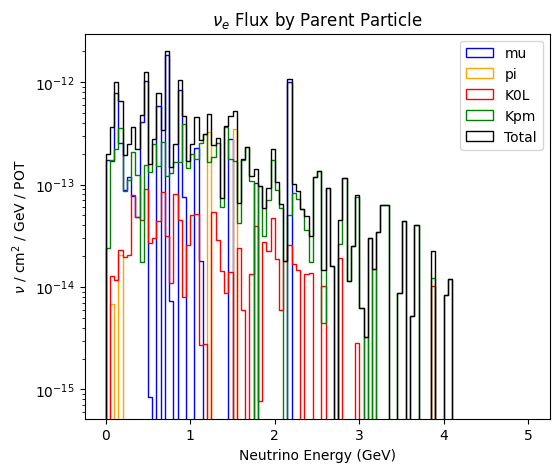

In [32]:
fig, ax = plt.subplots(figsize=(6, 5))
bins = np.linspace(0, 5, 101)  # GeV

for label, (parent_mask, colour) in parent_groups.items():
    mask = is_nue & parent_mask
    ax.hist(energies[mask], bins=bins, weights=tot_wgts[mask],
            label=label, color=colour, histtype="step", linewidth=1)

# Total Flux
ax.hist(energies[is_nue], bins=bins, weights=tot_wgts[is_nue], label="Total", 
        color="black", histtype="step", linewidth=1)

ax.set_xlabel("Neutrino Energy (GeV)")
ax.set_ylabel(r"$\nu$ / cm$^2$ / GeV / POT")
ax.set_title(r"$\nu_e$ Flux by Parent Particle")
ax.legend()
ax.set_yscale("log")

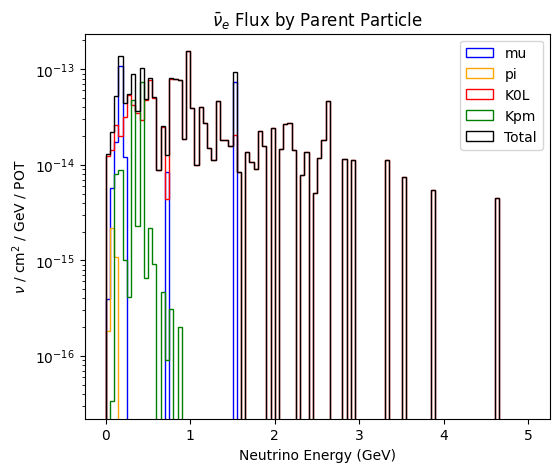

In [33]:
fig, ax = plt.subplots(figsize=(6, 5))
bins = np.linspace(0, 5, 101)  # GeV

for label, (parent_mask, colour) in parent_groups.items():
    mask = is_anue & parent_mask
    ax.hist(energies[mask], bins=bins, weights=tot_wgts[mask],
            label=label, color=colour, histtype="step", linewidth=1)

# Total Flux
ax.hist(energies[is_anue], bins=bins, weights=tot_wgts[is_anue], label="Total", 
        color="black", histtype="step", linewidth=1)

ax.set_xlabel("Neutrino Energy (GeV)")
ax.set_ylabel(r"$\nu$ / cm$^2$ / GeV / POT")
ax.set_title(r"$\bar{\nu}_e$ Flux by Parent Particle")
ax.legend()
ax.set_yscale("log")

## Estimate Event Rates

Text(0, 0.5, '')

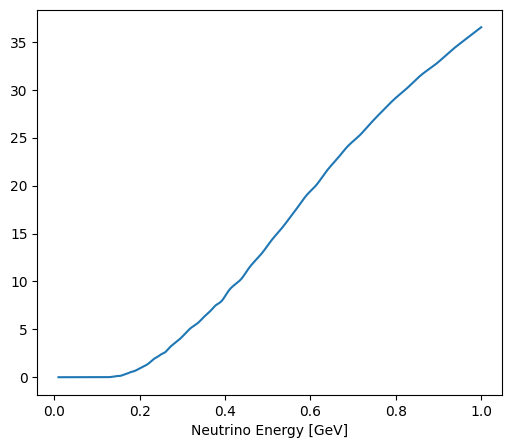

In [34]:
xsec = np.loadtxt("./DATA/numu_Ar_v3.04.00_t.AR23.20i.00.000.txt")
xsec_nuc = 1e-39 / 40 # Check units 
fig, ax = plt.subplots(figsize=(6,5))
ax.plot(xsec[:,0], xsec[:,1])
ax.set_xlabel("Neutrino Energy [GeV]")
ax.set_ylabel("")

In [35]:
# Same target?

rho = 1.38434 #g/cm^{3}
n_a = 6.022e23 #molec/mol
m_mol = 39.95 #g/mol
A = 40
volume_cm3 = 400*400*500

n_targets = (rho * volume_cm3 * n_a * A) / (m_mol)
print('Number of target nucleons: ', n_targets)

Number of target nucleons:  6.677543313141424e+31


Estimated SBND nue_1GeV events: 1.4666637780792046e-14
Estimated SBND anue_1GeV events: 1.597605751195847e-15
Estimated SBND numu_1GeV events: 4.704363906036125e-12
Estimated SBND anumu_1GeV events: 1.3182751167827907e-13


(0.0, 1.0)

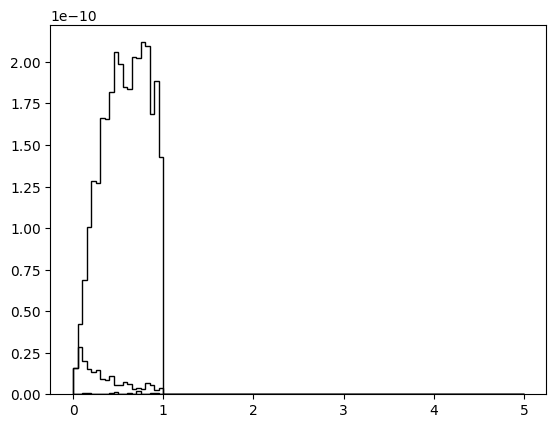

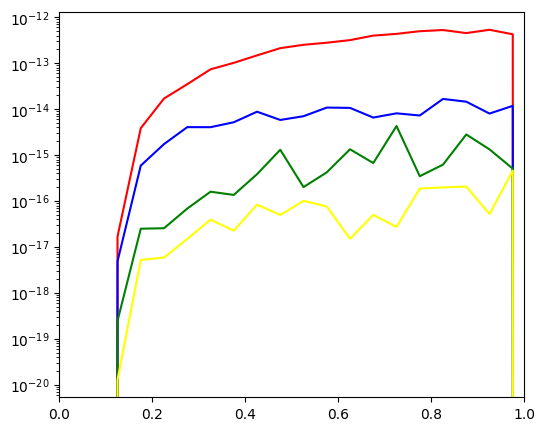

In [36]:
events = {
    'nue_1GeV': [],
    'anue_1GeV': [],
    'numu_1GeV': [],
    'anumu_1GeV': [],
}

masks =  [is_nue, is_anue, is_numu, is_anumu]
labels = events.keys()
# apply energy cut and flavour mask
energy_mask = (energies < 1)

for nu_type, label in zip(masks, labels):
    mask = nu_type & energy_mask

    # histogram the selected entries
    values, edges, _ = plt.hist(energies[mask], bins=bins, weights=tot_wgts[mask],
                            label="Total", color="black", histtype="step", linewidth=1)

    bin_centres = (edges[1:] + edges[:-1]) / 2

    for centre, val in zip(bin_centres, values):
        xsection = np.interp(centre, xsec[:,0], xsec[:,1] * xsec_nuc)
        evt = val * pots[0] * xsection * n_targets
        events[label].append(evt)

    print(f"Estimated SBND {label} events:", np.sum(events[label]))

fig, ax = plt.subplots(figsize=(6,5))
ax.plot(bin_centres, events["numu_1GeV"], color="red")
ax.plot(bin_centres, events["anumu_1GeV"], color="blue")
ax.plot(bin_centres, events["nue_1GeV"], color="green")
ax.plot(bin_centres, events["anue_1GeV"], color="yellow")
ax.set_yscale("log")
ax.set_xlim(0,1)
